# CellChat Control vs Mild vs severe

Cell-cellcommunication across control, IPF mild and IPF severe condition. This script generate the figure 7d-e, and supplementry figure 12.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from rpy2.rinterface import RRuntimeWarning
warnings.filterwarnings("ignore")

%load_ext rpy2.ipython

In [2]:
import os

# Force rpy2 and CellChat to use the correct R from Conda environment
os.environ['R_HOME'] = '/home/huijuanwang/miniconda3/envs/milopy/lib/R'
os.environ['PATH'] = '/home/huijuanwang/miniconda3/envs/milopy/bin:' + os.environ['PATH']

In [3]:
%%R
R.version.string
system("Rscript --version")

Rscript (R) version 4.4.3 (2025-02-28)


In [4]:
plot_folder = "/media/synology/Huijuan/snRNA IPF subset/cellchat/Plots/Control_Mild_Severe_selected_meta/"

In [5]:
#%%R
#install.packages('patchwork')
#install.packages('reticulate')
#install.packages('anndata')
#install.packages('NMF')
#install.packages('devtools')
#devtools::install_github("jokergoo/circlize")
#devtools::install_github("jokergoo/ComplexHeatmap")
#if (!require("BiocManager", quietly = TRUE))
    #install.packages("BiocManager")
#BiocManager::install("Biobase")
#BiocManager::install("BiocNeighbors")
#devtools::install_github('immunogenomics/presto')
#devtools::install_github("jinworks/CellChat")

In [6]:
%%R
library(CellChat)
library(patchwork)
library(anndata)
library(NMF)
library(ggalluvial)
options(stringsAsFactors = FALSE)
library(reticulate)
library(ggplot2)
theme_set(theme_gray(base_family = "Arial"))


    an issue that caused a segfault when used with rpy2:
    https://github.com/rstudio/reticulate/pull/1188
    Make sure that you use a version of that package that includes
    the fix.
    

Loading required package: dplyr

Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

Loading required package: igraph

Attaching package: ‘igraph’

The following objects are masked from ‘package:dplyr’:

    as_data_frame, groups, union

The following objects are masked from ‘package:stats’:

    decompose, spectrum

The following object is masked from ‘package:base’:

    union

Loading required package: ggplot2
Loading required package: registry
Loading required package: rngtools
Loading required package: cluster
NMF - BioConductor layer [OK] | Shared memory capabilities [NO: bigmemory] | Cores 2/2
  To enable shared memory capabilities, try: install.extras('
NMF
')

Attaching package: ‘NMF’

The following objects are masked from ‘package:igraph’:

    algorithm, compare



In [7]:
%%R
packageVersion("CellChat")

[1] ‘2.2.0’


## Load data

In [8]:
%%R
ad <- read_h5ad("/media/HDD_1/sc_data_objects/FibFoci/18082026_snRNA_IPF_annotation_final.h5ad")
# access normalized expression matrix (genes x cells)
data.input <- t(py_to_r(ad$X)) 
rownames(data.input) <- rownames(py_to_r(ad$var)) 
colnames(data.input) <- rownames(py_to_r(ad$obs)) 
# access meta data (columns)  
meta <- py_to_r(ad$obs)
table(meta$severity)


  Control   IPFMild IPFSevere 
    25936     20752     16384 


In [9]:
%%R
table(meta$meta)


               Aberrant basaloid                Airway epithelium 
                             196                             4458 
             Alveolar epithelium                          B cells 
                           17579                              999 
                    EC capillary                      EC vascular 
                            8147                             2587 
                     Fibroblasts                         Lymphoid 
                           11065                              929 
                         Myeloid                   Myofibroblasts 
                            7207                             1331 
                    Plasma cells                    SMC/Pericytes 
                            1112                             2024 
                         T cells VWA1+/PLVAP+ bronchial venous EC 
                            4742                              696 


In [10]:
%%R
unique(meta$cell_type)

 [1] Club                             Mast cells                      
 [3] AT1                              Plasma cells                    
 [5] CD4 T cells                      AT2                             
 [7] Alveolar fibroblasts             aCap                            
 [9] LGR5+ fibroblasts                Pericytes                       
[11] Alveolar macrophages             cMono                           
[13] Ciliated                         WNT5A+ fibroblasts              
[15] CD8 T cells                      Interstitial macrophages        
[17] Pulmonary venous EC              Adventitial fibroblasts         
[19] gCap                             Goblet                          
[21] Arterial EC                      DC activated                    
[23] Basal                            Myofibroblasts                  
[25] Aberrant basaloid                VWA1+/PLVAP+ bronchial venous EC
[27] NK cells                         DC2                             
[29] S

### Select celltypes of interest

In [11]:
%%R
celltypes_of_interest <- c('VWA1+/PLVAP+ bronchial venous EC', 'Myofibroblasts', 'Fibroblasts', 
                           'B cells', 'T cells', 'Plasma cells') 

meta <- meta %>% filter(meta %in% celltypes_of_interest)
meta$meta <- droplevels(meta$meta)
data.input <- data.input[, rownames(meta)]

In [12]:
%%R
cells_keep <- rownames(meta)[
    !meta$meta %in% c("Mesothelium")
]

meta <- meta[cells_keep, ]
data <- data.input[, cells_keep]

meta$meta <- droplevels(meta$meta)

table(meta$meta)


                         B cells                      Fibroblasts 
                             999                            11065 
                  Myofibroblasts                     Plasma cells 
                            1331                             1112 
                         T cells VWA1+/PLVAP+ bronchial venous EC 
                            4742                              696 


In [13]:
%%R
meta_ctrl <- meta[meta$severity == "Control", ]
meta_ctrl$meta <- droplevels(meta_ctrl$meta)   # <-- drop empty cell types
# Subset expression matrix accordingly
data_ctrl <- data.input[, rownames(meta_ctrl)]

In [14]:
%%R
meta_mild <- meta[meta$severity == "IPFMild", ]
meta_mild$meta <- droplevels(meta_mild$meta)
# Subset expression matrix accordingly
data_mild <- data.input[, rownames(meta_mild)]

In [15]:
%%R
meta_severe <- meta[meta$severity == "IPFSevere", ]
meta_severe$meta <- droplevels(meta_severe$meta)
# Subset expression matrix accordingly
data_severe <- data.input[, rownames(meta_severe)]

In [16]:
%%R
cellchat_ctrl <- createCellChat(object = data_ctrl, meta = meta_ctrl, group.by = "meta")
cellchat_mild <- createCellChat(object = data_mild, meta = meta_mild, group.by = "meta")
cellchat_severe <- createCellChat(object = data_severe, meta = meta_severe, group.by = "meta")
# Put into a list
object.list <- list(Control= cellchat_ctrl, Mild = cellchat_mild, Severe = cellchat_severe)
names(object.list)

[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  B cells, Fibroblasts, Myofibroblasts, Plasma cells, T cells, VWA1+/PLVAP+ bronchial venous EC 
[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  B cells, Fibroblasts, Myofibroblasts, Plasma cells, T cells, VWA1+/PLVAP+ bronchial venous EC 
[1] "Create a CellChat object from a data matrix"
Set cell identities for the new CellChat object 
The cell groups used for CellChat analysis are  B cells, Fibroblasts, Myofibroblasts, Plasma cells, T cells, VWA1+/PLVAP+ bronchial venous EC 
[1] "Control" "Mild"    "Severe" 


In addition: Warning messages:
1: In createCellChat(object = data_ctrl, meta = meta_ctrl, group.by = "meta") :
  The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 

2: In createCellChat(object = data_mild, meta = meta_mild, group.by = "meta") :
  The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 

3: In createCellChat(object = data_severe, meta = meta_severe, group.by = "meta") :
  The 'meta' data does not have a column named `samples`. We now add this column and all cells are assumed to belong to `sample1`! 



In [17]:
%%R
table(cellchat_ctrl@idents)


                         B cells                      Fibroblasts 
                              52                             4164 
                  Myofibroblasts                     Plasma cells 
                             116                              178 
                         T cells VWA1+/PLVAP+ bronchial venous EC 
                            1012                               95 


In [18]:
%%R
table(cellchat_mild@idents)


                         B cells                      Fibroblasts 
                              88                             3342 
                  Myofibroblasts                     Plasma cells 
                             704                              209 
                         T cells VWA1+/PLVAP+ bronchial venous EC 
                            1388                              205 


In [19]:
%%R
table(cellchat_severe@idents)


                         B cells                      Fibroblasts 
                             859                             3559 
                  Myofibroblasts                     Plasma cells 
                             511                              725 
                         T cells VWA1+/PLVAP+ bronchial venous EC 
                            2342                              396 


In [20]:
%%R
CellChatDB <- CellChatDB.human  # or CellChatDB.mouse depending on your data
showDatabaseCategory(CellChatDB)
# Show the structure of the database
#dplyr::glimpse(CellChatDB$interaction)

# use all CellChatDB except for "Non-protein Signaling" for cell-cell communication analysis
#CellChatDB.use <- subsetDB(CellChatDB, search = "Secreted Signaling", key = "annotation") # use Secreted Signaling
CellChatDB.use <- subsetDB(CellChatDB) # exclude non-protein signaling

In [21]:
%%R
for (i in 1:length(object.list)) {
  object.list[[i]]@DB <- CellChatDB.use  # assign database
  object.list[[i]] <- addMeta(object.list[[i]], meta = object.list[[i]]@meta)
  object.list[[i]] <- setIdent(object.list[[i]], ident.use = "meta")   # cell groups
  object.list[[i]] <- subsetData(object.list[[i]])
  object.list[[i]] <- identifyOverExpressedGenes(object.list[[i]])
  object.list[[i]] <- identifyOverExpressedInteractions(object.list[[i]])
  object.list[[i]] <- computeCommunProb(object.list[[i]])
  object.list[[i]] <- filterCommunication(object.list[[i]], min.cells = 10)
  object.list[[i]] <- computeCommunProbPathway(object.list[[i]])
  object.list[[i]] <- aggregateNet(object.list[[i]])
}

  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=00s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=00s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=01s  
The number of highly variable ligand-receptor pairs used for signaling inference is 1351 
triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run CellChat on sc/snRNA-seq data <<< [2026-08-26 17:02:14.069194]"
[1] ">>> CellChat inference is done. Parameter values are stored in `object@options$parameter` <<< [2026-08-26 17:04:09.942421]"
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=00s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=00s  
  |++++++++++++++++++++++++++++++++++++++++++++++++++| 100% elapsed=01s  
The number of highly variable ligand-receptor pairs used for signaling inference is 1453 
triMean is used for calculating the average gene expression per cell group. 
[1] ">>> Run Cel

  |======================================================================| 100%
  |======================================================================| 100%
  |======================================================================| 100%


In [22]:
%%R
cellchat <- mergeCellChat(object.list, add.names = names(object.list))

Merge the following slots: 'data.signaling','images','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.


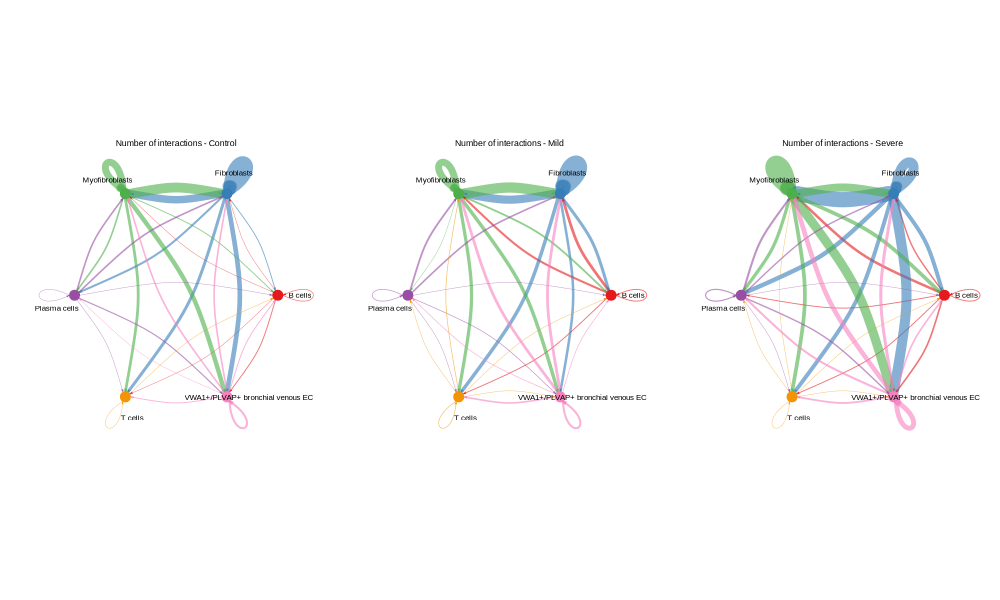

In [23]:
%%R -i plot_folder -w 1000 -h 600
# Circle plot showing the number of interactions or interaction strength among different cell populations across multiple datasets
weight.max <- getMaxWeight(object.list, attribute = c("idents","count"))
par(mfrow = c(1,3), xpd=TRUE)
for (i in 1:length(object.list)) {
  netVisual_circle(object.list[[i]]@net$count,
                   weight.scale = TRUE, #keep proportional scaling
                   #label.edge = TRUE,
                   edge.weight.max = weight.max[2], #sets a shared reference maximum
                   edge.width.max = 20, #controls the thickest line drawn
                   title.name = paste0("Number of interactions - ", names(object.list)[i]))
}

In [24]:
%%R
rownames(object.list[[1]]@net$count)

[1] "B cells"                          "Fibroblasts"                     
[3] "Myofibroblasts"                   "Plasma cells"                    
[5] "T cells"                          "VWA1+/PLVAP+ bronchial venous EC"


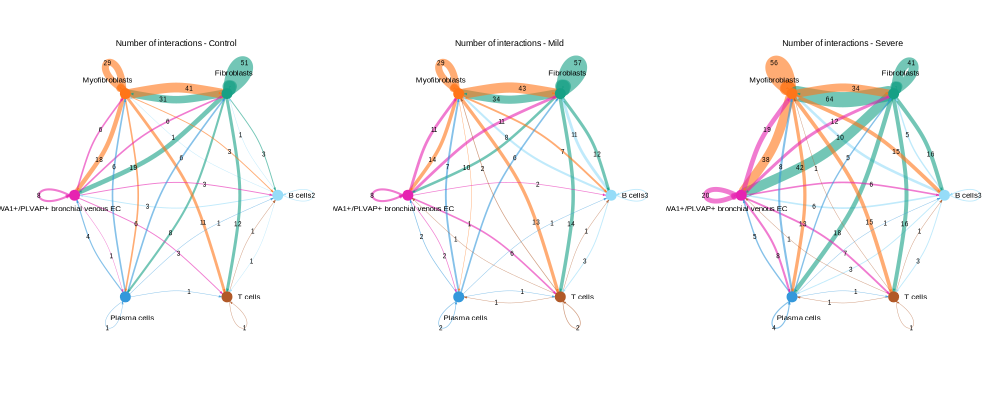

In [40]:
%%R -i plot_folder -w 1000 -h 400

# Define your desired order
my_order <- c("B cells", "Fibroblasts", "Myofibroblasts", "VWA1+/PLVAP+ bronchial venous EC", "Plasma cells", "T cells")

my_colors <- c(
  "B cells"                         = "#96DCF8",
  "Fibroblasts"                     = '#16A085',
  "Myofibroblasts"                  = "#FF7518",
  "Plasma cells"                    = "#3498db",
  "T cells"                         = "#b15928",
  "VWA1+/PLVAP+ bronchial venous EC" = "#E623B1"  
)

weight.max <- getMaxWeight(object.list, attribute = c("idents","count"))

par(mfrow = c(1,3), xpd=TRUE)
for (i in 1:length(object.list)) {
  # reorder rows and columns of the count matrix to match my_order
  mat <- object.list[[i]]@net$count[my_order, my_order]
  
  netVisual_circle(mat,
                   color.use = my_colors[my_order],
                   weight.scale = TRUE,
                   label.edge = TRUE,
                   edge.weight.max = weight.max[2],
                   edge.width.max = 20,
                   title.name = paste0("Number of interactions - ", names(object.list)[i]))
}

In [41]:
%%R -i plot_folder

pdf(
    file.path(plot_folder, "CellChat_interaction_circle.pdf"),
    width = 10,
    height = 4
)

my_colors <- c(
  "B cells"                         = "#96DCF8",
  "Fibroblasts"                     = '#16A085',
  "Myofibroblasts"                  = "#FF7518",
  "VWA1+/PLVAP+ bronchial venous EC" = "#E623B1",
  "Plasma cells"                    = "#3498db",
  "T cells"                         = "#b15928"
)
weight.max <- getMaxWeight(
    object.list,
    attribute = c("idents","count")
)

par(mfrow = c(1,3), xpd = TRUE)

for (i in 1:length(object.list)) {

  netVisual_circle(
      object.list[[i]]@net$count,
      color.use = my_colors,
      weight.scale = TRUE,
      label.edge = TRUE,
      edge.weight.max = weight.max[2],
      edge.width.max = 20,
      title.name = paste(
          "Number of interactions -",
          names(object.list)[i]
      )
  )
}

dev.off()

png 
  2 


## Outgoing signaling

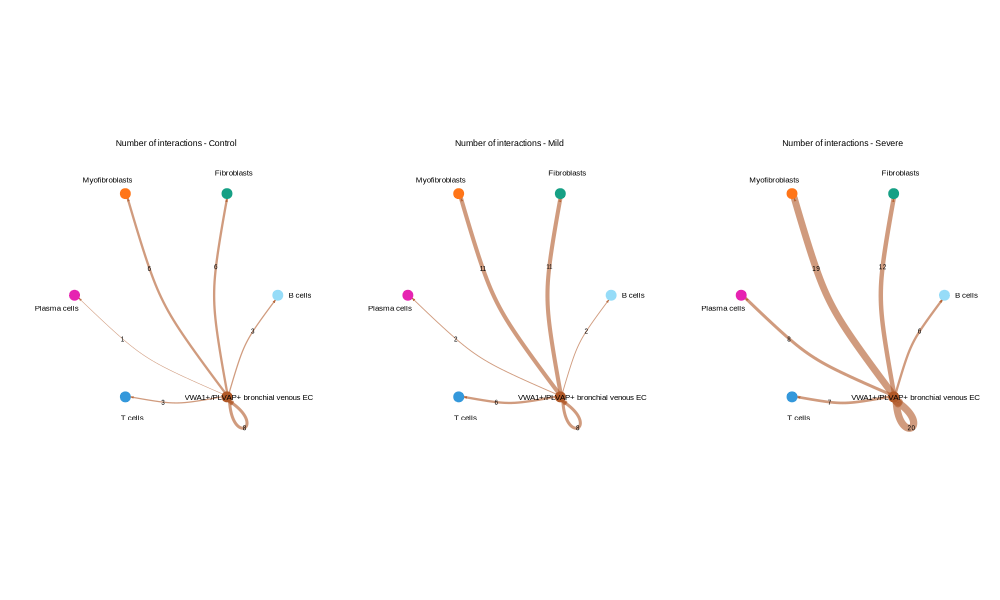

In [42]:
%%R -i plot_folder -w 1000 -h 600

# Circle plot showing the number of interactions or interaction strength among different cell populations across multiple datasets
weight.max <- getMaxWeight(object.list, attribute = c("idents","count"))
par(mfrow = c(1,3), xpd=TRUE)
for (i in 1:length(object.list)) {
  netVisual_circle(object.list[[i]]@net$count,
                   color.use = my_colors,
                   weight.scale = TRUE, #keep proportional scaling
                   label.edge = TRUE,
                   sources.use = "VWA1+/PLVAP+ bronchial venous EC", 
                   edge.weight.max = weight.max[2], #sets a shared reference maximum
                   edge.width.max = 30, #controls the thickest line drawn
                   title.name = paste0("Number of interactions - ", names(object.list)[i]))
}

In [43]:
%%R
# Extract communication table
df.list <- lapply(names(object.list), function(nm){
    df <- subsetCommunication(object.list[[nm]])
    df$dataset <- nm
    df
})
colnames(df.list[[1]])

 [1] "source"             "target"             "ligand"            
 [4] "receptor"           "prob"               "pval"              
 [7] "interaction_name"   "interaction_name_2" "pathway_name"      
[10] "annotation"         "evidence"           "dataset"           


In [44]:
%%R
# Combine list into single dataframe
df.net <- bind_rows(df.list)
# Quick check
dim(df.net)
head(df.net)

        source         target  ligand     receptor        prob pval
1  Fibroblasts    Fibroblasts    BMP5 BMPR1A_BMPR2 0.005281491    0
2  Fibroblasts Myofibroblasts    BMP5 BMPR1A_BMPR2 0.005281491    0
3 Plasma cells    Fibroblasts    BMP6 BMPR1A_BMPR2 0.014271584    0
4 Plasma cells Myofibroblasts    BMP6 BMPR1A_BMPR2 0.014271584    0
5      B cells    Fibroblasts ANGPTL1  ITGA1_ITGB1 0.024743356    0
6 Plasma cells    Fibroblasts ANGPTL1  ITGA1_ITGB1 0.006302803    0
     interaction_name      interaction_name_2 pathway_name         annotation
1   BMP5_BMPR1A_BMPR2   BMP5 - (BMPR1A+BMPR2)          BMP Secreted Signaling
2   BMP5_BMPR1A_BMPR2   BMP5 - (BMPR1A+BMPR2)          BMP Secreted Signaling
3   BMP6_BMPR1A_BMPR2   BMP6 - (BMPR1A+BMPR2)          BMP Secreted Signaling
4   BMP6_BMPR1A_BMPR2   BMP6 - (BMPR1A+BMPR2)          BMP Secreted Signaling
5 ANGPTL1_ITGA1_ITGB1 ANGPTL1 - (ITGA1+ITGB1)       ANGPTL Secreted Signaling
6 ANGPTL1_ITGA1_ITGB1 ANGPTL1 - (ITGA1+ITGB1)       ANGP

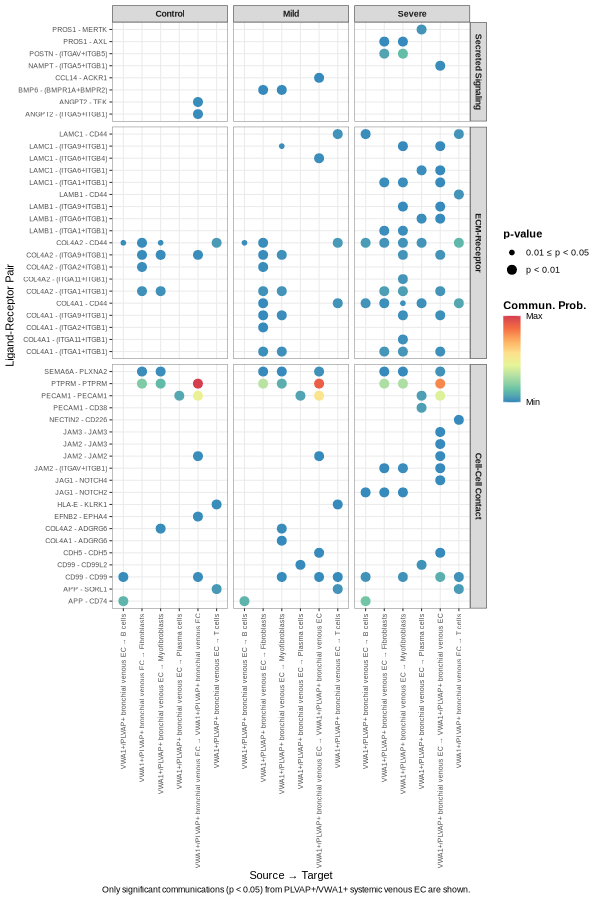

In [46]:
%%R -w 600 -h 900
# 1. Select significant PLVAP → target communications
df.plot <- subset(df.net, source == "VWA1+/PLVAP+ bronchial venous EC" & pval < 0.05)

# 2. Define significance categories
df.plot$p.group <- ifelse(df.plot$pval < 0.01, "p < 0.01", "0.01 ≤ p < 0.05")
df.plot$p.group <- factor(df.plot$p.group, levels = c("0.01 ≤ p < 0.05", "p < 0.01"))

# 3. Set annotation order
df.plot$annotation <- factor(df.plot$annotation, levels = c("Secreted Signaling", "ECM-Receptor", "Cell-Cell Contact"))

# 4. Set target order, then build Source → Target labels in that order
target_order <- c("B cells", "Fibroblasts", "Myofibroblasts", "Plasma cells", 
                   "VWA1+/PLVAP+ bronchial venous EC", "T cells")
df.plot$target <- factor(df.plot$target, levels = target_order)
df.plot <- df.plot[order(df.plot$target), ]  # sort rows so x_label factor levels follow this order

df.plot$x_label <- paste(df.plot$source, "→", df.plot$target)
df.plot$x_label <- factor(df.plot$x_label, levels = unique(df.plot$x_label))  # lock in the order

df.plot$interaction_name_2 <- droplevels(factor(df.plot$interaction_name_2))

# 5. Generate communication plot
p <- ggplot(df.plot, aes(x = x_label, y = interaction_name_2)) +
  geom_point(aes(size = p.group, color = prob)) +
  facet_grid(annotation ~ dataset, scales = "free", space = "free") +
  scale_size_manual(name = "p-value", values = c("0.01 ≤ p < 0.05" = 2, "p < 0.01" = 4)) +
  scale_color_gradientn(colors = c("#3288BD", "#66C2A5", "#ABDDA4", "#E6F598", "#FEE08B", "#FDAE61", "#F46D43", "#D53E4F"), 
                        limits = c(0, max(df.plot$prob, na.rm = TRUE)), breaks = c(0, max(df.plot$prob, na.rm = TRUE)), labels = c("Min", "Max"), 
                        name = "Commun. Prob.", na.value = "grey90") +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5, size = 7), 
        axis.text.y = element_text(size = 7), strip.text = element_text(face = "bold"), panel.border = element_rect(linewidth = 0.3),
        legend.title = element_text(face = "bold"), legend.text = element_text(size = 9)) +
  labs(x = "Source → Target", y = "Ligand-Receptor Pair", 
       caption = "Only significant communications (p < 0.05) from PLVAP+/VWA1+ systemic venous EC are shown.")
p

In [47]:
%%R
ggsave(
    file.path(
        plot_folder,
        "PLVAP_target_3condition.pdf"
    ),
    p,
    width = 8,
    height = 13
)

In [48]:
%%R
# Check what sources are actually in df.plot
table(df.plot$source)


                         B cells                      Fibroblasts 
                               0                                0 
                  Myofibroblasts                     Plasma cells 
                               0                                0 
                         T cells VWA1+/PLVAP+ bronchial venous EC 
                               0                              139 


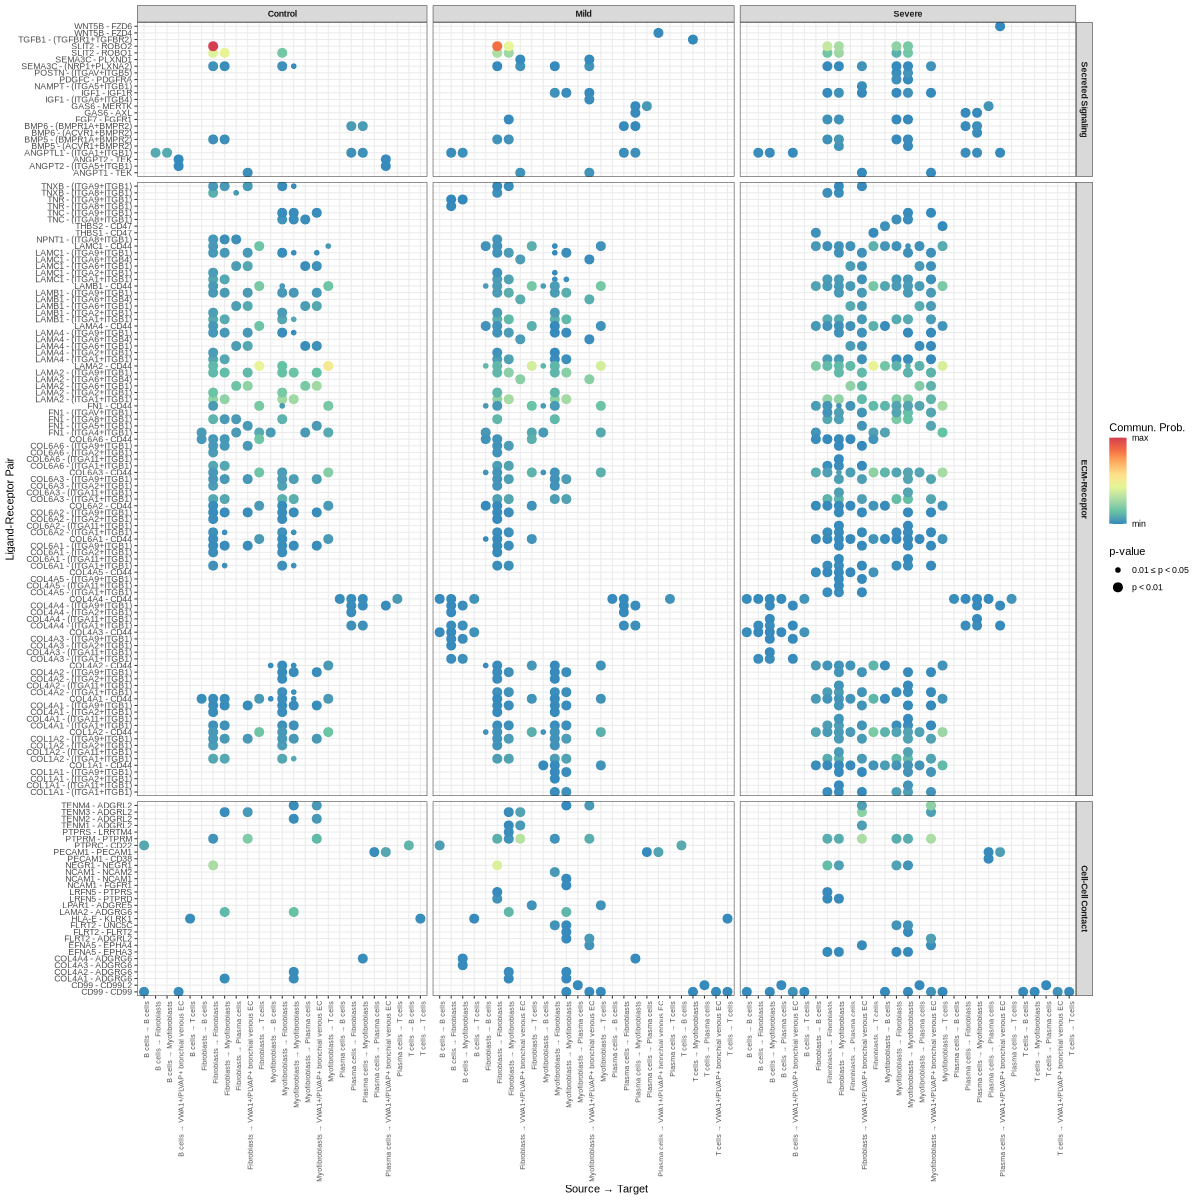

In [50]:
%%R -w 1200 -h 1200
library(ggplot2)

# 1. Define sources and targets of interest
sources_of_interest <- c("Myofibroblasts", "Fibroblasts", "B cells", "T cells", "Plasma cells")
targets_of_interest <- c("VWA1+/PLVAP+ bronchial venous EC", "Myofibroblasts", "Fibroblasts", "B cells", "T cells", "Plasma cells")

# 2. Select source-target interactions and retain only significant communications
df.plot <- df.net[df.net$source %in% sources_of_interest & df.net$target %in% targets_of_interest & df.net$pval < 0.05, ]

# 3. Define two significance categories
df.plot$p.group <- ifelse(df.plot$pval < 0.01, "p < 0.01", "0.01 ≤ p < 0.05")
df.plot$p.group <- factor(df.plot$p.group, levels = c("0.01 ≤ p < 0.05", "p < 0.01"))

# 4. Set signaling category order
df.plot$annotation <- factor(df.plot$annotation, levels = c("Secreted Signaling", "ECM-Receptor", "Cell-Cell Contact"))

# 5. Set cell type order for both source and target, then sort rows accordingly
cell_order <- c("B cells", "Fibroblasts", "Myofibroblasts", "Plasma cells", 
                "VWA1+/PLVAP+ bronchial venous EC", "T cells")
df.plot$source <- factor(df.plot$source, levels = cell_order)
df.plot$target <- factor(df.plot$target, levels = cell_order)
df.plot <- df.plot[order(df.plot$source, df.plot$target), ]

# 6. Create Source → Target labels, locked in the sorted order
df.plot$x_label <- paste(df.plot$source, "→", df.plot$target)
df.plot$x_label <- factor(df.plot$x_label, levels = unique(df.plot$x_label))

# 7. Drop unused factor levels
df.plot$interaction_name_2 <- droplevels(factor(df.plot$interaction_name_2))

# 8. Generate communication plot
pp <- ggplot(df.plot, aes(x = x_label, y = interaction_name_2)) +
  geom_point(aes(size = p.group, color = prob)) +
  facet_grid(annotation ~ dataset, scales = "free", space = "free") +
  scale_size_manual(name = "p-value", values = c("0.01 ≤ p < 0.05" = 2, "p < 0.01" = 4)) +
  scale_color_gradientn(colors = c("#3288BD", "#66C2A5", "#ABDDA4", "#E6F598", "#FEE08B", "#FDAE61", "#F46D43", "#D53E4F"), 
                        limits = c(0, max(df.plot$prob, na.rm = TRUE)), breaks = c(0, max(df.plot$prob, na.rm = TRUE)), 
                        labels = c("min", "max"), na.value = "grey90") +
  theme_bw() +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, size = 7), strip.text = element_text(face = "bold")) +
  labs(x = "Source → Target", y = "Ligand-Receptor Pair", size = "p-value", color = "Commun. Prob.")
pp

In [51]:
%%R
ggsave(
    file.path(
        plot_folder,
        "selected_cell_comunication.pdf"
    ),
    pp,
    width = 18,
    height = 22
)